# CFG Sweep apr14 — Analysis

Results from `sweep_apr14`: `prop` × `trans_frac` × 3 seeds, tense-separate translation, input-masked.

**Plots:**
1. Metrics over time by proportion (avg ± SD over seeds)
2. Loss curves (train, eval) by proportion
3. Heatmaps: final metrics as prop × trans_frac
4. Results broken down by structure type
5. Codeswitching dynamics & translation effect

In [5]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RESULTS_ROOT = Path(
    "/n/netscratch/dam_lab/Lab/drooryck/codeswitching-llms/"
    "april_exp/cfg/results/sweep_apr14/runs"
)

sys.path.insert(0, str(Path.home() / "codeswitching-llms"))
from april_exp.cfg.src.metrics import Metrics
METRICS_OBJ = Metrics(Path.home() / "codeswitching-llms/april_exp/cfg/data/lexicon.json")

/n/home06/drooryck/envs/codeswitching-py310/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Load data

In [6]:
all_metrics = []
run_summary = []

for run_dir in sorted(RESULTS_ROOT.iterdir()):
    m = re.match(r"mask_(\w+)_prop([\d.]+)_tf([\d.]+)_run(\d+)", run_dir.name)
    if not m:
        continue
    level, prop, tf, run_id = m.group(1), float(m.group(2)), float(m.group(3)), int(m.group(4))

    mf = run_dir / "eval_sample_metrics.csv"
    if not mf.exists():
        continue
    df = pd.read_csv(mf)
    if df.empty:
        continue
    df["level"] = level
    df["prop"] = prop
    df["tf"] = tf
    df["run_id"] = run_id
    all_metrics.append(df)

    final = df.iloc[-1]
    row = {"level": level, "prop": prop, "tf": tf, "run_id": run_id,
           "final_step": int(final["step"])}
    for lang in ("en", "nl"):
        for met in ("lexical", "syntax", "conformity", "pos_validity", "pos_coverage", "exact_match"):
            col = f"{lang}_{met}"
            if col in df.columns:
                row[f"{col}_final"] = final[col]
    run_summary.append(row)

metrics_df = pd.concat(all_metrics, ignore_index=True)
summary_df = pd.DataFrame(run_summary)
print(f"Loaded {len(summary_df)} runs, {len(metrics_df)} metric rows")
print(f"Props:  {sorted(summary_df['prop'].unique())}")
print(f"TFs:    {sorted(summary_df['tf'].unique())}")
print(f"Seeds:  {sorted(summary_df['run_id'].unique())}")

Loaded 243 runs, 23193 metric rows
Props:  [np.float64(0.0), np.float64(0.01), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(0.99), np.float64(1.0)]
TFs:    [np.float64(0.0), np.float64(0.01), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(0.99), np.float64(1.0)]
Seeds:  [np.int64(1), np.int64(2), np.int64(3)]


In [7]:
# Each test_predictions.csv is 13MB / 86K rows. 243 runs = 3.2GB.
# Load on demand for specific subsets only.

def load_test_preds(prop=None, tf=None, run_id=None, max_runs=30):
    """Load test_predictions.csv for a filtered subset of runs."""
    dfs = []
    for run_dir in sorted(RESULTS_ROOT.iterdir()):
        m = re.match(r"mask_(\w+)_prop([\d.]+)_tf([\d.]+)_run(\d+)", run_dir.name)
        if not m:
            continue
        r_prop, r_tf, r_id = float(m.group(2)), float(m.group(3)), int(m.group(4))
        if prop is not None and r_prop != prop:
            continue
        if tf is not None and r_tf != tf:
            continue
        if run_id is not None and r_id != run_id:
            continue
        pf = run_dir / "test_predictions.csv"
        if not pf.exists():
            continue
        df = pd.read_csv(pf)
        df["level"] = m.group(1)
        df["prop"] = r_prop
        df["tf"] = r_tf
        df["run_id"] = r_id
        dfs.append(df)
        if len(dfs) >= max_runs:
            break
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print("load_test_preds() ready — e.g. load_test_preds(tf=0.0) loads 27 runs (~2.3M rows)")

load_test_preds() ready — e.g. load_test_preds(tf=0.0) loads 27 runs (~2.3M rows)


## 1. Metrics over time by proportion (tf=0)

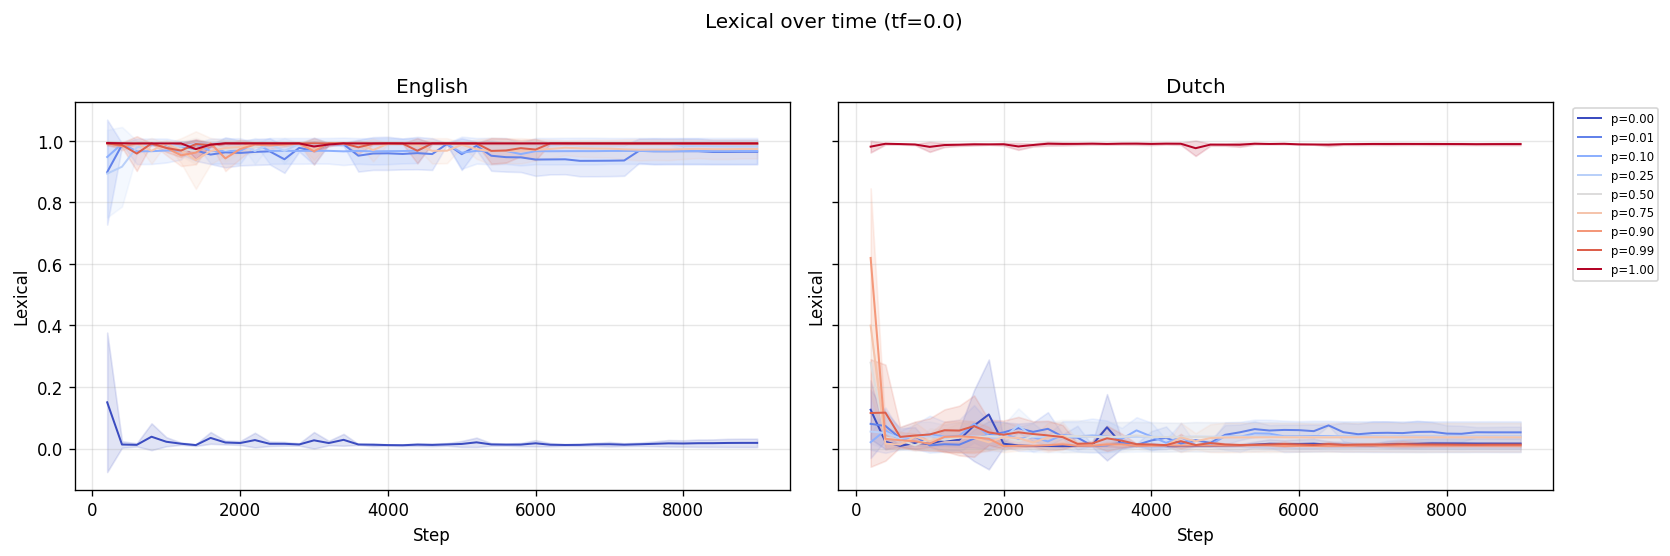

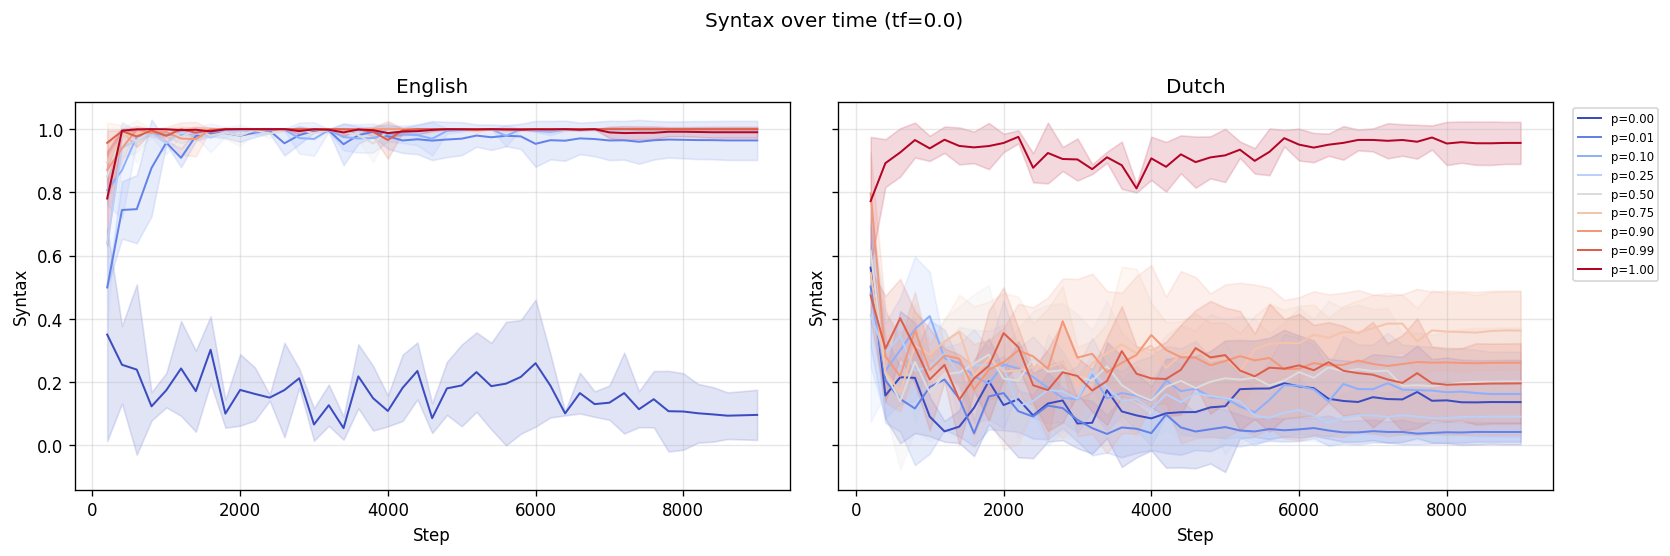

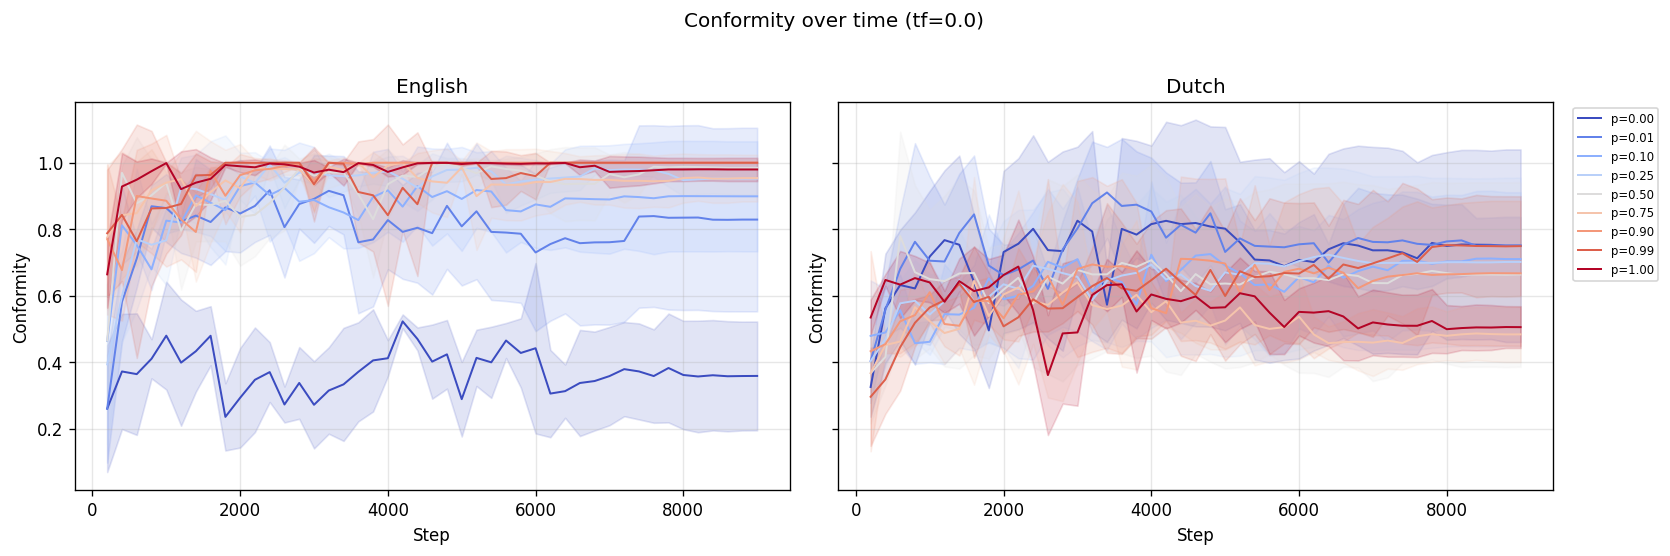

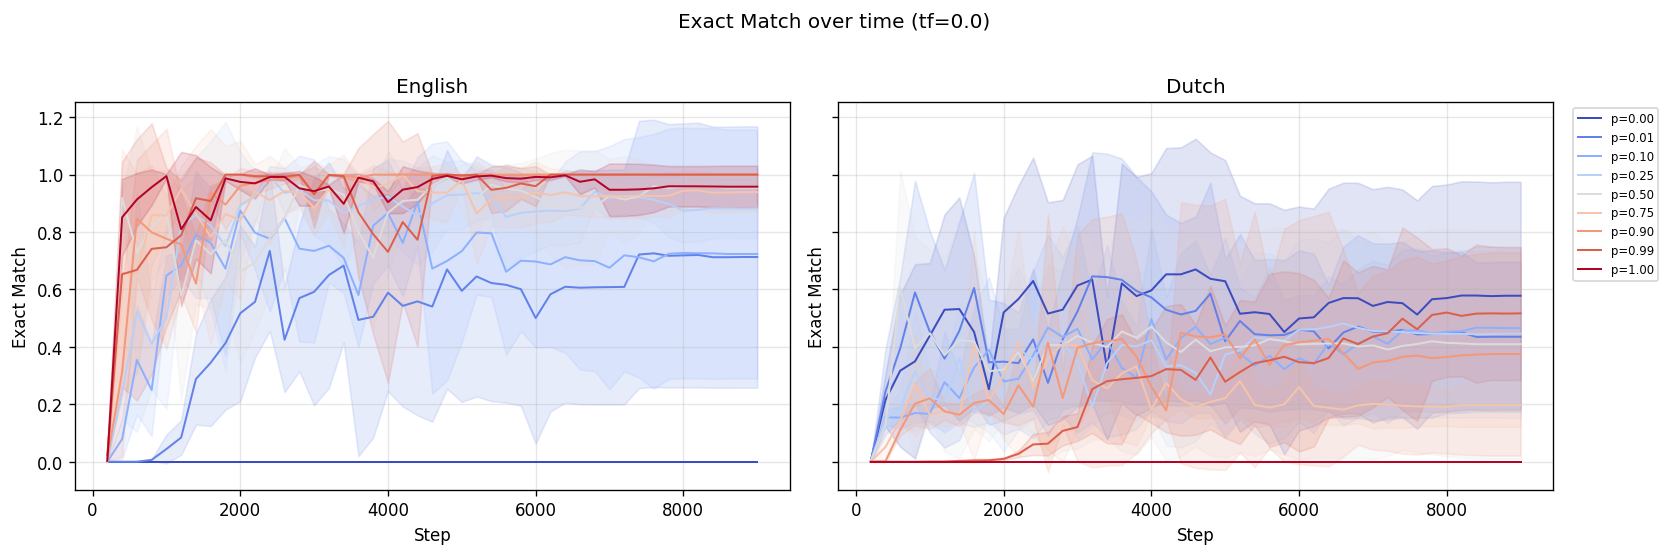

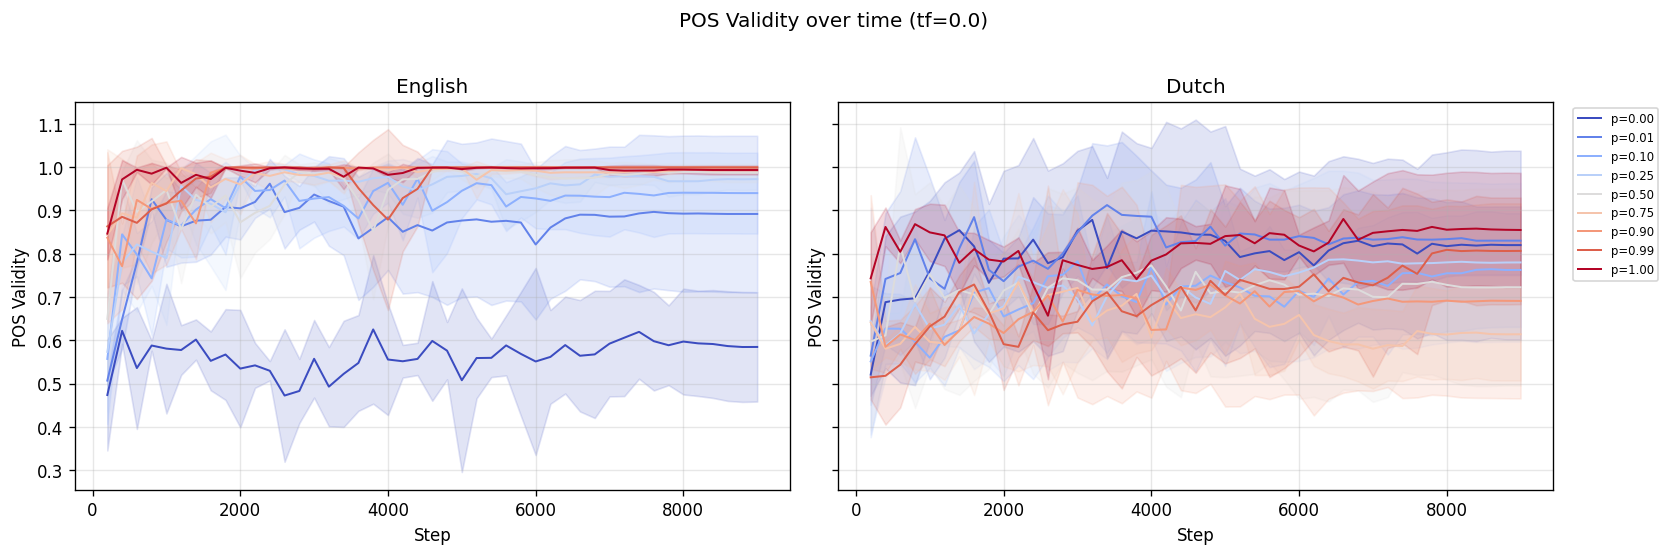

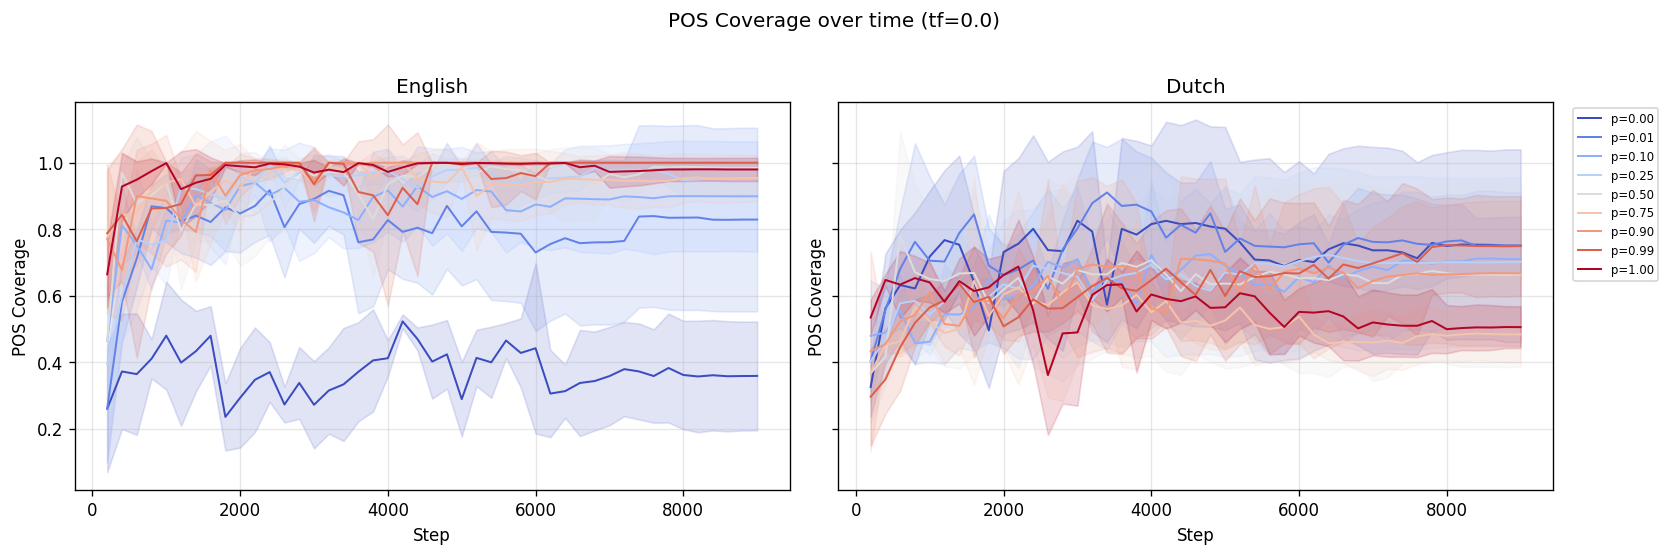

In [8]:
def plot_metric_over_time(df, metric, fixed_tf=0.0):
    sub = df[df["tf"] == fixed_tf]
    props = sorted(sub["prop"].unique())
    cmap = plt.cm.coolwarm
    colors = [cmap(i / max(len(props)-1, 1)) for i in range(len(props))]
    nice = {"lexical": "Lexical", "syntax": "Syntax", "conformity": "Conformity",
            "exact_match": "Exact Match", "pos_validity": "POS Validity",
            "pos_coverage": "POS Coverage"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    for ax, lang, title in zip(axes, ["en", "nl"], ["English", "Dutch"]):
        col = f"{lang}_{metric}"
        if col not in sub.columns:
            continue
        for c, p in zip(colors, props):
            g = sub[sub["prop"]==p].groupby("step")[col]
            mn, sd = g.mean(), g.std().fillna(0)
            ax.plot(mn.index, mn.values, color=c, label=f"p={p:.2f}", lw=1.2)
            ax.fill_between(mn.index, mn-sd, mn+sd, color=c, alpha=0.15)
        ax.set_xlabel("Step"); ax.set_ylabel(nice.get(metric, metric))
        ax.set_title(title); ax.grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    fig.suptitle(f"{nice.get(metric, metric)} over time (tf={fixed_tf})", y=1.02)
    fig.tight_layout()
    plt.show()

for metric in ("lexical", "syntax", "conformity", "exact_match", "pos_validity", "pos_coverage"):
    plot_metric_over_time(metrics_df, metric, fixed_tf=0.0)

## 2. Loss curves

In [9]:
# Load trainer_state.json logs
all_logs = []
for run_dir in sorted(RESULTS_ROOT.iterdir()):
    m = re.match(r"mask_(\w+)_prop([\d.]+)_tf([\d.]+)_run(\d+)", run_dir.name)
    if not m:
        continue
    for candidate in [run_dir / "trainer_state.json"] + list(run_dir.glob("checkpoint-*/trainer_state.json")):
        if candidate.exists():
            with open(candidate) as f:
                state = json.load(f)
            for entry in state.get("log_history", []):
                entry["prop"] = float(m.group(2))
                entry["tf"] = float(m.group(3))
                entry["run_id"] = int(m.group(4))
                all_logs.append(entry)
            break
logs_df = pd.DataFrame(all_logs) if all_logs else pd.DataFrame()
print(f"Log entries: {len(logs_df)}")

Log entries: 0


In [10]:
if not logs_df.empty:
    sub = logs_df[logs_df["tf"] == 0.0]
    props = sorted(sub["prop"].unique())
    cmap = plt.cm.coolwarm
    colors = [cmap(i / max(len(props)-1, 1)) for i in range(len(props))]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, col, title in [(axes[0], "loss", "Training Loss"), (axes[1], "eval_loss", "Eval Loss")]:
        d = sub.dropna(subset=[col])
        for c, p in zip(colors, props):
            g = d[d["prop"]==p].groupby("step")[col]
            mn = g.mean()
            sd = g.std().fillna(0)
            ax.plot(mn.index, mn.values, color=c, label=f"p={p:.2f}", lw=1)
            ax.fill_between(mn.index, mn-sd, mn+sd, color=c, alpha=0.1)
        ax.set_xlabel("Step"); ax.set_ylabel(col); ax.set_title(title)
        ax.grid(True, alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
    fig.suptitle("Loss curves (tf=0)", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No training logs found yet.")

No training logs found yet.


## 3. Heatmaps: final metrics (prop × trans_frac)

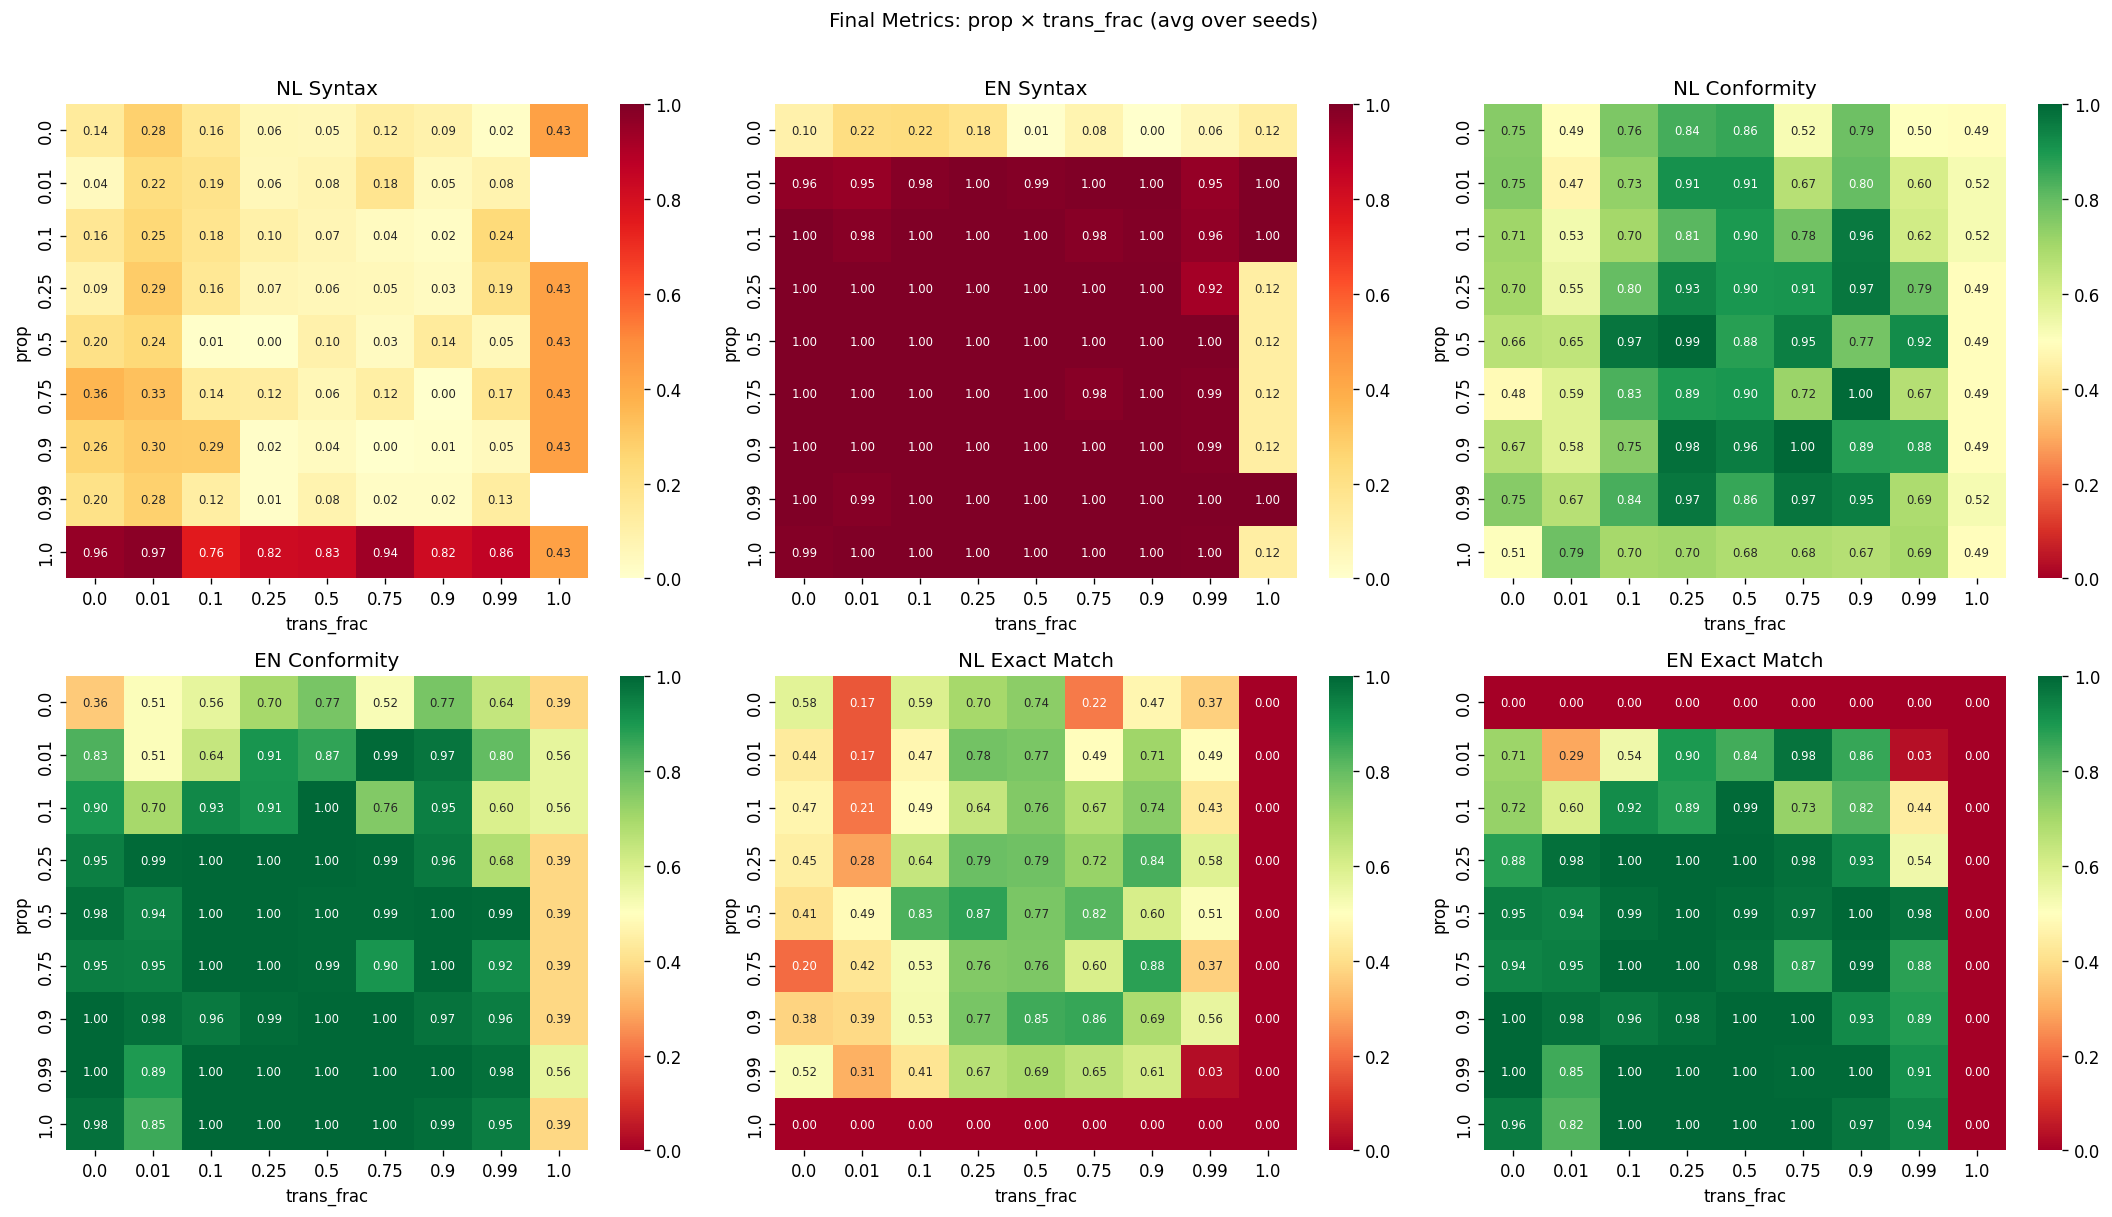

In [11]:
hm_metrics = [
    ("nl_syntax_final", "NL Syntax", "YlOrRd"),
    ("en_syntax_final", "EN Syntax", "YlOrRd"),
    ("nl_conformity_final", "NL Conformity", "RdYlGn"),
    ("en_conformity_final", "EN Conformity", "RdYlGn"),
    ("nl_exact_match_final", "NL Exact Match", "RdYlGn"),
    ("en_exact_match_final", "EN Exact Match", "RdYlGn"),
]

available = [(c, n, cm) for c, n, cm in hm_metrics if c in summary_df.columns]
if available:
    n = len(available)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, (col, name, cm) in zip(axes, available):
        pivot = summary_df.groupby(["prop", "tf"])[col].mean().unstack("tf")
        sns.heatmap(pivot, ax=ax, vmin=0, vmax=1, cmap=cm,
                    annot=True, fmt=".2f", annot_kws={"size": 7})
        ax.set_title(name); ax.set_xlabel("trans_frac"); ax.set_ylabel("prop")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    fig.suptitle("Final Metrics: prop × trans_frac (avg over seeds)", y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("No summary data available yet.")

## 4. Results by structure type

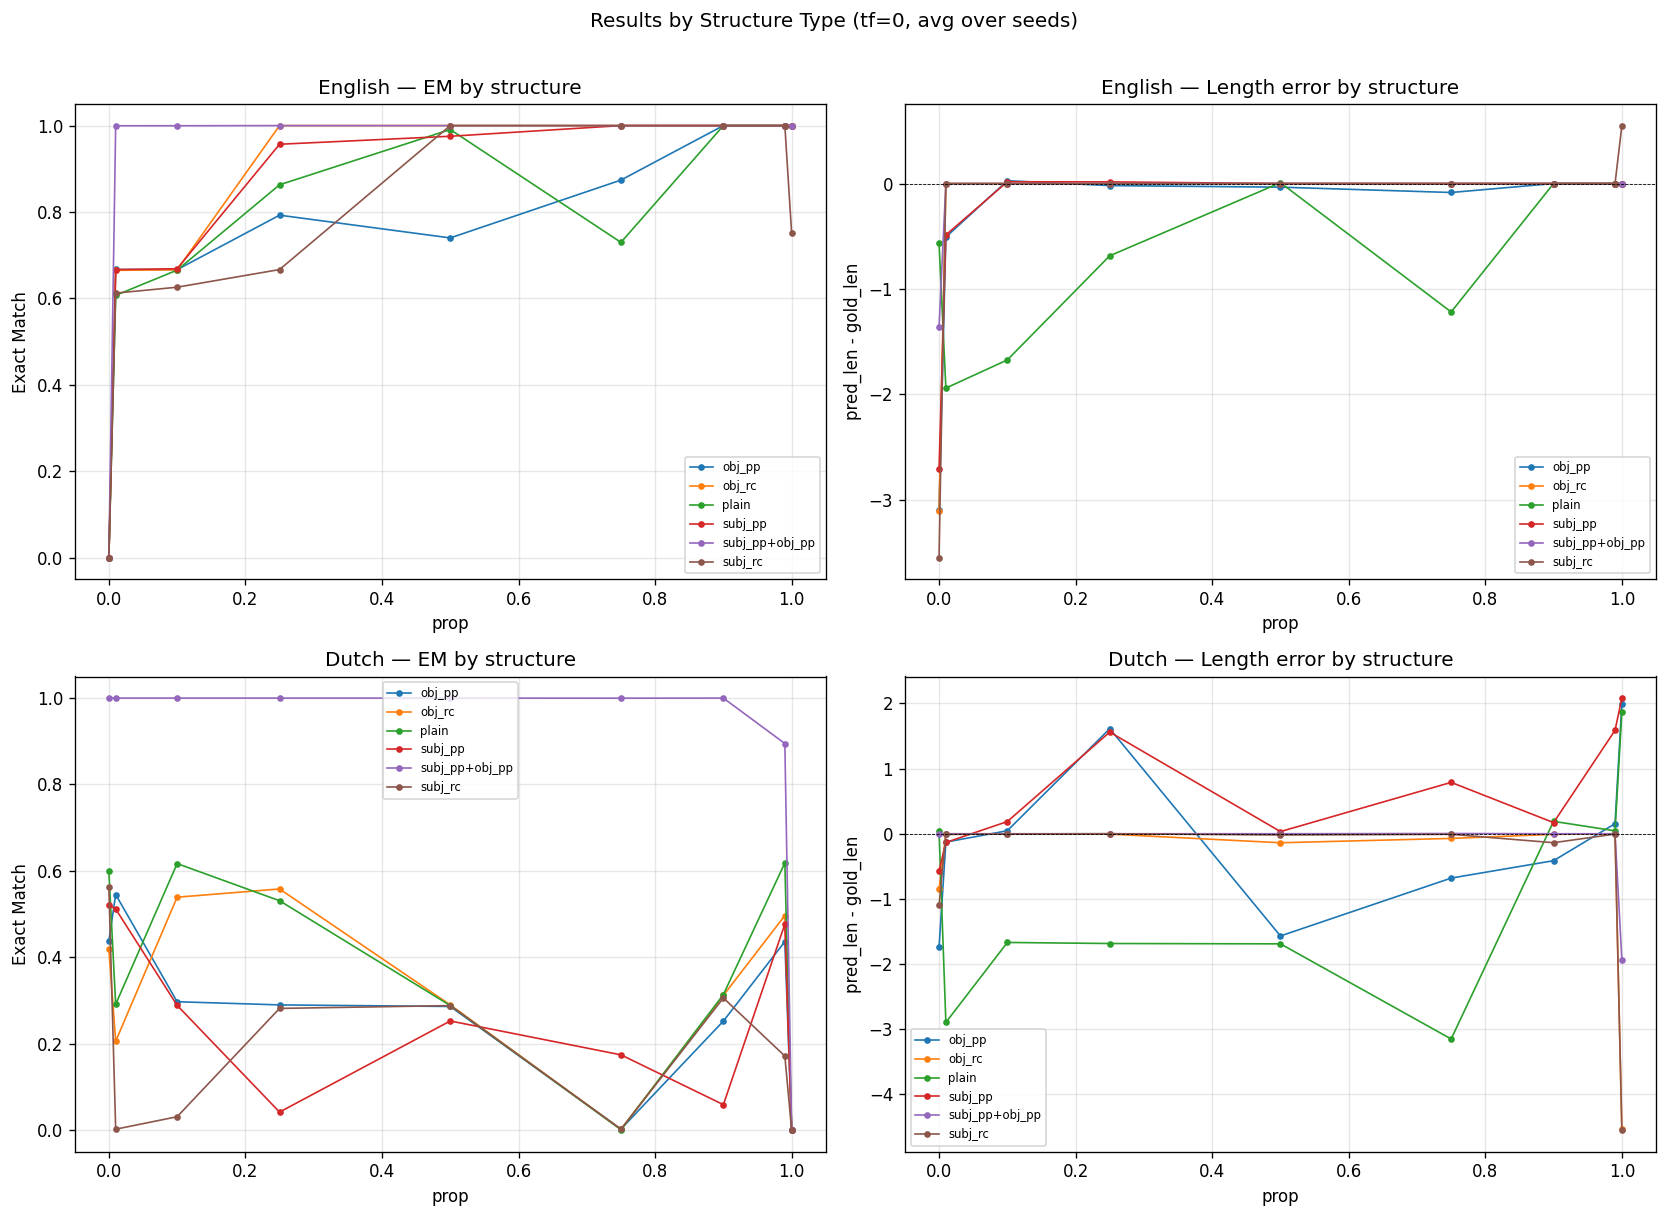

In [12]:
# Load only tf=0 predictions (27 runs, ~2.3M rows, ~30s)
preds_tf0 = load_test_preds(tf=0.0)

if not preds_tf0.empty and "structure" in preds_tf0.columns:
    preds_tf0["em"] = (preds_tf0["prediction"] == preds_tf0["gold"]).astype(float)

    tf0 = preds_tf0
    structures = sorted(tf0["structure"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for row_idx, (lang, title) in enumerate([("en", "English"), ("nl", "Dutch")]):
        lang_df = tf0[tf0["language"] == lang]

        # EM by structure
        ax = axes[row_idx, 0]
        for s in structures:
            sub = lang_df[lang_df["structure"]==s].groupby("prop")["em"].mean()
            ax.plot(sub.index, sub.values, marker="o", ms=3, lw=1, label=s)
        ax.set_title(f"{title} — EM by structure"); ax.set_xlabel("prop")
        ax.set_ylabel("Exact Match"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        # Pred length error by structure
        ax = axes[row_idx, 1]
        ldf = lang_df.copy()
        ldf["pred_len"] = ldf["prediction"].apply(lambda x: len(str(x).split()))
        ldf["gold_len"] = ldf["gold"].apply(lambda x: len(str(x).split()))
        ldf["len_diff"] = ldf["pred_len"] - ldf["gold_len"]
        for s in structures:
            sub = ldf[ldf["structure"]==s].groupby("prop")["len_diff"].mean()
            ax.plot(sub.index, sub.values, marker="o", ms=3, lw=1, label=s)
        ax.axhline(0, color="k", ls="--", lw=0.5)
        ax.set_title(f"{title} — Length error by structure"); ax.set_xlabel("prop")
        ax.set_ylabel("pred_len - gold_len"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle("Results by Structure Type (tf=0, avg over seeds)", y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("No test predictions available yet.")

## 5. Codeswitching dynamics & translation effect

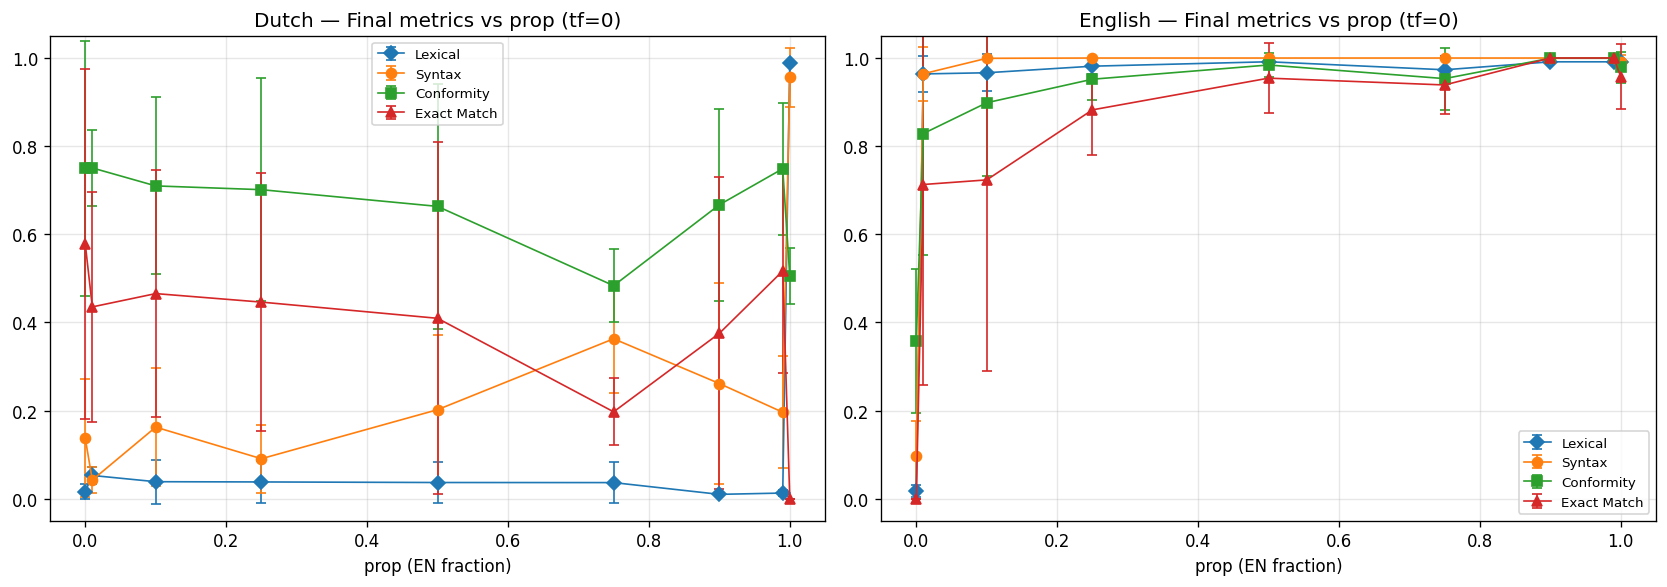

In [13]:
# Final NL/EN metrics vs prop (tf=0) with error bars over seeds
sub = metrics_df[metrics_df["tf"] == 0.0]
final = sub.groupby(["prop", "run_id"]).last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lang, title in zip(axes, ["nl", "en"], ["Dutch", "English"]):
    for met, mk, lab in [(f"{lang}_lexical", "D", "Lexical"),
                         (f"{lang}_syntax", "o", "Syntax"),
                         (f"{lang}_conformity", "s", "Conformity"),
                         (f"{lang}_exact_match", "^", "Exact Match")]:
        if met not in final.columns:
            continue
        mn = final.groupby("prop")[met].mean()
        sd = final.groupby("prop")[met].std().fillna(0)
        ax.errorbar(mn.index, mn.values, yerr=sd.values,
                    marker=mk, label=lab, capsize=3, lw=1)
    ax.set_title(f"{title} — Final metrics vs prop (tf=0)")
    ax.set_xlabel("prop (EN fraction)"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
plt.show()

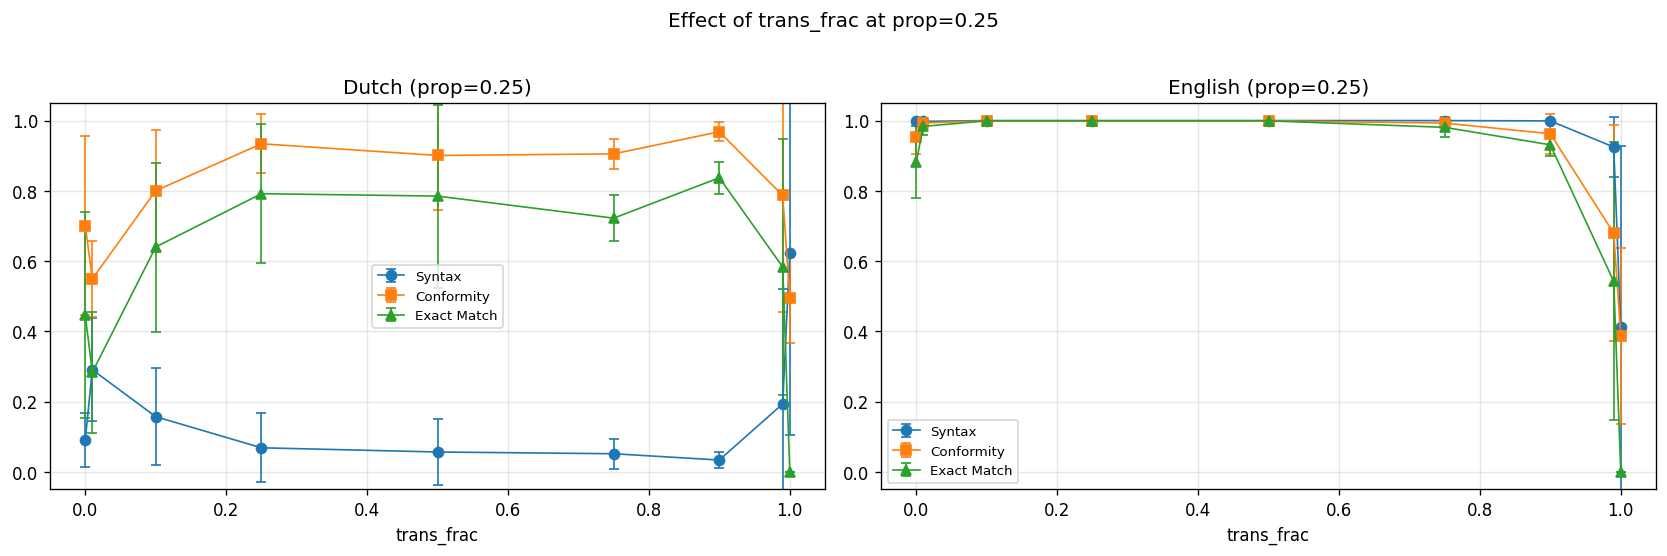

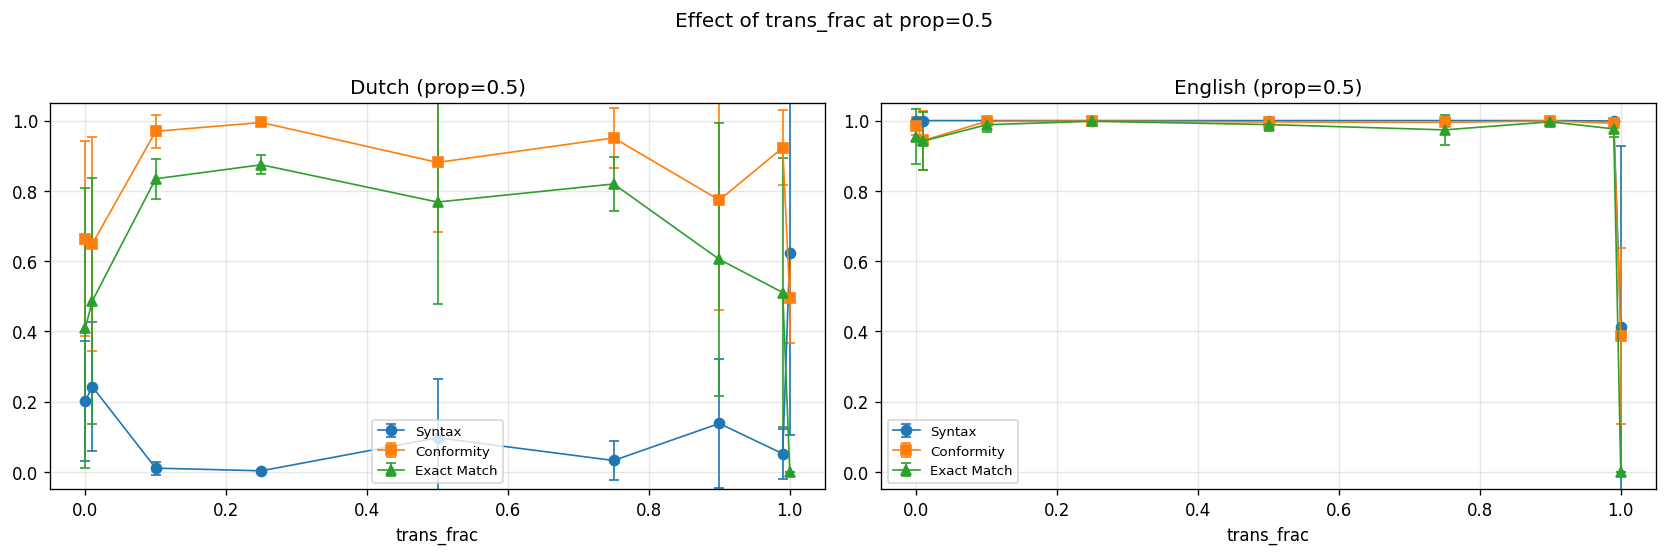

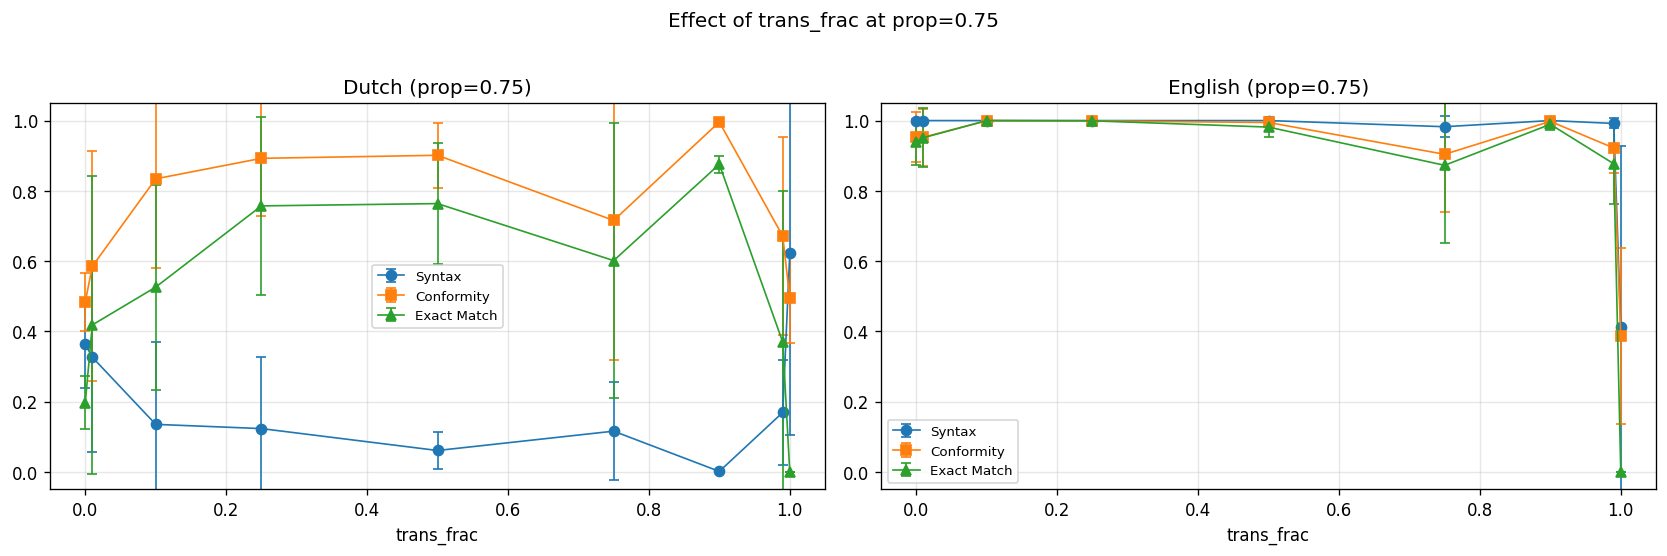

In [14]:
# Translation effect: at prop=0.5, how does trans_frac affect metrics?
for target_prop in [0.25, 0.5, 0.75]:
    sub = metrics_df[metrics_df["prop"] == target_prop]
    if sub.empty:
        continue
    final = sub.groupby(["tf", "run_id"]).last().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, lang, title in zip(axes, ["nl", "en"], ["Dutch", "English"]):
        for met, mk, lab in [(f"{lang}_syntax", "o", "Syntax"),
                             (f"{lang}_conformity", "s", "Conformity"),
                             (f"{lang}_exact_match", "^", "Exact Match")]:
            if met not in final.columns:
                continue
            mn = final.groupby("tf")[met].mean()
            sd = final.groupby("tf")[met].std().fillna(0)
            ax.errorbar(mn.index, mn.values, yerr=sd.values,
                        marker=mk, label=lab, capsize=3, lw=1)
        ax.set_title(f"{title} (prop={target_prop})")
        ax.set_xlabel("trans_frac"); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.05)
    fig.suptitle(f"Effect of trans_frac at prop={target_prop}", y=1.02)
    fig.tight_layout()
    plt.show()

## 6. Prediction explorer

In [15]:
def explore(prop=0.5, tf=0.0, seed=1, lang="nl", structure=None,
            n=20, only_wrong=False, only_correct=False):
    """Inspect predictions for a specific run.

    Args:
        prop: EN fraction in conjugation (0-1)
        tf: translation fraction (0-1)
        seed: random seed (1, 2, or 3)
        lang: "en" or "nl" (or None for both)
        structure: filter to a specific structure type (e.g. "plain", "subj_rc")
        n: max number of examples to show
        only_wrong: only show incorrect predictions
        only_correct: only show correct predictions
    """
    df = load_test_preds(prop=prop, tf=tf, run_id=seed, max_runs=1)
    if df.empty:
        print(f"No predictions found for prop={prop}, tf={tf}, seed={seed}")
        return df

    if lang is not None:
        df = df[df["language"] == lang]
    if structure is not None:
        df = df[df["structure"] == structure]

    df = df.copy()
    df["correct"] = df["prediction"] == df["gold"]
    if only_wrong:
        df = df[~df["correct"]]
    elif only_correct:
        df = df[df["correct"]]

    total = len(df)
    n_correct = df["correct"].sum()
    print(f"prop={prop}, tf={tf}, seed={seed}, lang={lang}, structure={structure}")
    print(f"  {n_correct}/{total} correct ({100*n_correct/total:.1f}%)")
    if structure is None and "structure" in df.columns:
        for s in sorted(df["structure"].unique()):
            ss = df[df["structure"] == s]
            sc = ss["correct"].sum()
            print(f"    {s:20s}: {sc}/{len(ss)} ({100*sc/len(ss):.1f}%)")
    print()

    sample = df.head(n)
    for _, r in sample.iterrows():
        tag = "OK" if r["correct"] else "WRONG"
        struct = r.get("structure", "?")
        print(f"  [{r.get('language','?').upper()}] [{struct}] {tag}")
        print(f"    in:   {r['input']}")
        print(f"    gold: {r['gold']}")
        print(f"    pred: {r['prediction']}")
        if not r["correct"]:
            gold_toks = str(r["gold"]).split()
            pred_toks = str(r["prediction"]).split()
            diffs = []
            for i in range(max(len(gold_toks), len(pred_toks))):
                g = gold_toks[i] if i < len(gold_toks) else "∅"
                p = pred_toks[i] if i < len(pred_toks) else "∅"
                if g != p:
                    diffs.append(f"pos {i}: {g!r} → {p!r}")
            if diffs:
                print(f"    diff: {'; '.join(diffs)}")
        print()
    return df

# Example usage:
explore(prop=0.5, tf=0.0, seed=1, lang="nl", n=15, only_wrong=True)
# else:
#     print("No test predictions available yet.")

prop=0.5, tf=0.0, seed=1, lang=nl, structure=None
  0/6046 correct (0.0%)
    obj_pp              : 0/1033 (0.0%)
    obj_rc              : 0/928 (0.0%)
    plain               : 0/984 (0.0%)
    subj_pp             : 0/2077 (0.0%)
    subj_rc             : 0/1024 (0.0%)

  [NL] [obj_pp] WRONG
    in:   het schaap negeert de vossen onder de spin
    gold: het schaap heeft de vossen onder de spin genegeerd
    pred: de schaap heeft de vossen onder de spin genegeerd
    diff: pos 0: 'het' → 'de'

  [NL] [plain] WRONG
    in:   de dokters nemen het varken
    gold: de dokters hebben het varken genomen
    pred: het dokters hebben het varken genomen
    diff: pos 0: 'de' → 'het'

  [NL] [subj_pp] WRONG
    in:   de krab achter het paard troost de muggen
    gold: de krab achter het paard heeft de muggen getroost
    pred: achter het achter het paard heeft de muggen getroost
    diff: pos 0: 'de' → 'achter'; pos 1: 'krab' → 'het'

  [NL] [subj_pp] WRONG
    in:   de ezel in de tijgers achte

,language,input,gold,prediction,structure,level,prop,tf,run_id,correct
3,nl,het schaap negeert de vossen onder de spin,het schaap heeft de vossen onder de spin geneg...,de schaap heeft de vossen onder de spin genegeerd,obj_pp,none,0.5,0.0,1,False
14,nl,de dokters nemen het varken,de dokters hebben het varken genomen,het dokters hebben het varken genomen,plain,none,0.5,0.0,1,False
19,nl,de krab achter het paard troost de muggen,de krab achter het paard heeft de muggen getroost,achter het achter het paard heeft de muggen ge...,subj_pp,none,0.5,0.0,1,False
29,nl,de ezel in de tijgers achtervolgt de vissen,de ezel in de tijgers heeft de vissen achtervolgd,in de in de tijgers heeft de vissen achtervolgd,subj_pp,none,0.5,0.0,1,False
30,nl,het hert sluit de eenden die de muizen bekijken,het hert heeft de eenden die de muizen bekijke...,de hert heeft de eenden die de muizen bekijken...,obj_rc,none,0.5,0.0,1,False
...,...,...,...,...,...,...,...,...,...,...
85932,nl,de hagedissen gooien het kind naast de hond,de hagedissen hebben het kind naast de hond ge...,hebben het kind,obj_pp,none,0.5,0.0,1,False
85940,nl,de leeuwen in de vlinder dragen de kip,de leeuwen in de vlinder hebben de kip gedragen,in de in de vlinder hebben de kip gedragen,subj_pp,none,0.5,0.0,1,False
85941,nl,het hert naast de hagedis wacht de beer,het hert naast de hagedis heeft de beer gewacht,naast de naast de hagedis heeft de beer gewacht,subj_pp,none,0.5,0.0,1,False
85948,nl,de eend die het schaap bouwt bewaart de kraaien,de eend die het schaap bouwt heeft de kraaien ...,het eend die het schaap bouwt heeft de kraaien...,subj_rc,none,0.5,0.0,1,False


In [16]:
# Try different settings — edit and re-run this cell
# explore(prop=0.0, tf=0.0, seed=1, lang="nl", n=15, only_wrong=True)
# explore(prop=0.5, tf=0.5, seed=1, lang="nl", n=15, only_wrong=True)
# explore(prop=0.5, tf=0.0, seed=1, lang="nl", structure="plain", n=15)
# explore(prop=0.75, tf=0.0, seed=1, lang="nl", n=15, only_wrong=True)
# explore(prop=0.5, tf=0.25, seed=1, lang="nl", n=15)

explore(prop=0.5, tf=0.0, seed=1, lang="nl", structure="plain", n=10, only_wrong=True)

prop=0.5, tf=0.0, seed=1, lang=nl, structure=plain
  0/984 correct (0.0%)

  [NL] [plain] WRONG
    in:   de dokters nemen het varken
    gold: de dokters hebben het varken genomen
    pred: het dokters hebben het varken genomen
    diff: pos 0: 'de' → 'het'

  [NL] [plain] WRONG
    in:   het schaap vernietigt de aap
    gold: het schaap heeft de aap vernietigd
    pred: de schaap heeft de aap vernietigd
    diff: pos 0: 'het' → 'de'

  [NL] [plain] WRONG
    in:   het konijn ziet de bijen
    gold: het konijn heeft de bijen gezien
    pred: de konijn heeft de bijen gezien
    diff: pos 0: 'het' → 'de'

  [NL] [plain] WRONG
    in:   de leraars vinden het hert
    gold: de leraars hebben het hert gevonden
    pred: het leraars hebben het hert gevonden
    diff: pos 0: 'de' → 'het'

  [NL] [plain] WRONG
    in:   het konijn zoent de vogels
    gold: het konijn heeft de vogels gezoend
    pred: de konijn heeft de vogels gezoend
    diff: pos 0: 'het' → 'de'

  [NL] [plain] WRONG
    in:

,language,input,gold,prediction,structure,level,prop,tf,run_id,correct
14,nl,de dokters nemen het varken,de dokters hebben het varken genomen,het dokters hebben het varken genomen,plain,none,0.5,0.0,1,False
73,nl,het schaap vernietigt de aap,het schaap heeft de aap vernietigd,de schaap heeft de aap vernietigd,plain,none,0.5,0.0,1,False
81,nl,het konijn ziet de bijen,het konijn heeft de bijen gezien,de konijn heeft de bijen gezien,plain,none,0.5,0.0,1,False
179,nl,de leraars vinden het hert,de leraars hebben het hert gevonden,het leraars hebben het hert gevonden,plain,none,0.5,0.0,1,False
245,nl,het konijn zoent de vogels,het konijn heeft de vogels gezoend,de konijn heeft de vogels gezoend,plain,none,0.5,0.0,1,False
...,...,...,...,...,...,...,...,...,...,...
85347,nl,het kind opent de gans,het kind heeft de gans geopend,de kind heeft de gans geopend,plain,none,0.5,0.0,1,False
85576,nl,het schaap mag de vlinder,het schaap heeft de vlinder gemogen,de schaap heeft de vlinder gemogen,plain,none,0.5,0.0,1,False
85595,nl,de krabben verliezen het kind,de krabben hebben het kind verloren,het krabben hebben het kind verloren,plain,none,0.5,0.0,1,False
85854,nl,het hert sluit de mug,het hert heeft de mug gesloten,de hert heeft de mug gesloten,plain,none,0.5,0.0,1,False


In [17]:
# Compare NL accuracy across seeds to understand the high variance
for seed in [1, 2, 3]:
    explore(prop=0.5, tf=0.0, seed=seed, lang="nl", n=0)

prop=0.5, tf=0.0, seed=1, lang=nl, structure=None
  36946/42992 correct (85.9%)
    obj_pp              : 6193/7226 (85.7%)
    obj_rc              : 6237/7165 (87.0%)
    plain               : 6175/7159 (86.3%)
    subj_pp             : 4978/7055 (70.6%)
    subj_pp+obj_pp      : 7141/7141 (100.0%)
    subj_rc             : 6222/7246 (85.9%)

prop=0.5, tf=0.0, seed=2, lang=nl, structure=None
  7538/42992 correct (17.5%)
    obj_pp              : 2/7224 (0.0%)
    obj_rc              : 1/7200 (0.0%)
    plain               : 11/7136 (0.2%)
    subj_pp             : 367/7062 (5.2%)
    subj_pp+obj_pp      : 7125/7125 (100.0%)
    subj_rc             : 32/7245 (0.4%)

prop=0.5, tf=0.0, seed=3, lang=nl, structure=None
  7191/42992 correct (16.7%)
    obj_pp              : 0/7202 (0.0%)
    obj_rc              : 0/7164 (0.0%)
    plain               : 0/7159 (0.0%)
    subj_pp             : 0/7048 (0.0%)
    subj_pp+obj_pp      : 7186/7186 (100.0%)
    subj_rc             : 5/7233 (0.1%)



In [ ]:
# Sweep across props: NL error patterns
for p in [0.0, 0.25, 0.5, 0.75, 1.0]:
    df = explore(prop=p, tf=0.0, seed=1, lang="nl", n=0)
    if df is not None and not df.empty:
        wrong = df[df["prediction"] != df["gold"]]
        if len(wrong) > 0:
            pred_lens = wrong["prediction"].str.split().str.len()
            gold_lens = wrong["gold"].str.split().str.len()
            print(f"  pred len stats: mean={pred_lens.mean():.1f}, median={pred_lens.median():.0f}")
            print(f"  gold len stats: mean={gold_lens.mean():.1f}, median={gold_lens.median():.0f}")
            len_match = (pred_lens == gold_lens).sum()
            print(f"  length match: {len_match}/{len(wrong)} ({100*len_match/len(wrong):.1f}%)")
        print()

prop=0.0, tf=0.0, seed=1, lang=nl, structure=None
  28990/42992 correct (67.4%)
    obj_pp              : 2780/7226 (38.5%)
    obj_rc              : 2759/7165 (38.5%)
    plain               : 6172/7159 (86.2%)
    subj_pp             : 4260/7055 (60.4%)
    subj_pp+obj_pp      : 7141/7141 (100.0%)
    subj_rc             : 5878/7246 (81.1%)

  pred len stats: mean=9.2, median=9
  gold len stats: mean=9.2, median=9
  length match: 13992/14002 (99.9%)

prop=0.25, tf=0.0, seed=1, lang=nl, structure=None
  32674/42992 correct (76.0%)
    obj_pp              : 6197/7226 (85.8%)
    obj_rc              : 6237/7165 (87.0%)
    plain               : 6175/7159 (86.3%)
    subj_pp             : 806/7055 (11.4%)
    subj_pp+obj_pp      : 7141/7141 (100.0%)
    subj_rc             : 6118/7246 (84.4%)

  pred len stats: mean=8.9, median=9
  gold len stats: mean=8.9, median=9
  length match: 10318/10318 (100.0%)

prop=0.5, tf=0.0, seed=1, lang=nl, structure=None
  36946/42992 correct (85.9%)
    o

: 